# 08 - Apresentacao EDA STJ

Notebook de apoio para uma apresentacao de 30 minutos sobre o corpus STJ Integras, recorte 2024-2026.

A ideia e usar os artefatos ja salvos em `data/reports/summaries`, sem reler todos os metadados brutos durante a apresentacao.

## Roteiro sugerido para 30 minutos

1. **Pergunta e fonte dos dados** - 3 min
2. **Escala do corpus** - 5 min
3. **Evolucao temporal** - 5 min
4. **Composicao documental e resultados decisorios** - 6 min
5. **Concentracoes tematicas** - 7 min
6. **Limites atuais e proximos passos** - 4 min

## Escopo e unidade de analise

**Mensagem oral:** esta EDA descreve o corpus de **documentos publicados pelo STJ** entre 2024 e 2026. Ela ainda nao reconstrói a vida processual completa desde a origem em primeira/segunda instancia.

- Unidade observada agora: `SeqDocumento` / documento de integra.
- Chaves auxiliares disponiveis: `processo`, `numeroRegistro` e, quando existir, CNJ normalizado.
- Unidade desejada para a pesquisa longitudinal: processo, com percurso entre instancias, movimentacoes, recursos e decisoes.

Portanto, os numeros desta apresentacao sao bons para entender escala, composicao documental e concentracoes tematicas do corpus STJ. Eles ainda nao devem ser apresentados como uma contagem definitiva de trajetorias processuais completas.

In [3]:
escopo = pd.DataFrame([
    {'camada': 'Documento STJ', 'chave': 'SeqDocumento', 'status': 'capturado nos metadados/ZIPs', 'uso': 'texto, tipo documental, teor, assunto'},
    {'camada': 'Registro STJ', 'chave': 'numeroRegistro', 'status': 'capturado nos metadados', 'uso': 'agrupar quando CNJ nao aparece'},
    {'camada': 'Processo CNJ', 'chave': 'numero_processo', 'status': 'parcial/depende de normalizacao e cruzamentos', 'uso': 'vida processual e origem'},
    {'camada': 'Outras instancias', 'chave': 'CNJ + movimentos', 'status': 'proxima etapa', 'uso': 'trajetoria longitudinal completa'},
])
display(escopo)

,camada,chave,status,uso
0,Documento STJ,SeqDocumento,capturado nos metadados/ZIPs,"texto, tipo documental, teor, assunto"
1,Registro STJ,numeroRegistro,capturado nos metadados,agrupar quando CNJ nao aparece
2,Processo CNJ,numero_processo,parcial/depende de normalizacao e cruzamentos,vida processual e origem
3,Outras instancias,CNJ + movimentos,proxima etapa,trajetoria longitudinal completa


## 1. Ambiente

In [2]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 180)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})

print('Imports loaded.')

Imports loaded.


In [4]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'notebooks').exists() and (candidate / 'README.md').exists():
            return candidate
        if candidate.name == 'datajud_probe':
            return candidate
    return start

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = find_project_root(Path.cwd())

if IN_COLAB:
    MOUNT_POINT = Path('/content/drive')
    if (MOUNT_POINT / 'MyDrive').exists():
        print('Google Drive ja esta montado.')
    else:
        drive.mount(str(MOUNT_POINT), force_remount=True)
    DATA_ROOT = MOUNT_POINT / 'MyDrive/Mestrado/2026/llms/data'
else:
    DATA_ROOT = PROJECT_ROOT / 'data'

REPORTS_DATA = DATA_ROOT / 'reports' / 'summaries'
FIGURES_DATA = DATA_ROOT / 'reports' / 'figures' / 'apresentacao_eda'
FIGURES_DATA.mkdir(parents=True, exist_ok=True)

print('DATA_ROOT:', DATA_ROOT)
print('REPORTS_DATA:', REPORTS_DATA, 'exists=', REPORTS_DATA.exists())
print('FIGURES_DATA:', FIGURES_DATA)

Google Drive ja esta montado.
DATA_ROOT: /content/drive/MyDrive/Mestrado/2026/llms/data
REPORTS_DATA: /content/drive/MyDrive/Mestrado/2026/llms/data/reports/summaries exists= True
FIGURES_DATA: /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda


## 2. Carregar tabelas resumidas

In [5]:
def load_csv(name: str, required: bool = True) -> pd.DataFrame:
    path = REPORTS_DATA / name
    if not path.exists():
        if required:
            raise FileNotFoundError(f'Arquivo nao encontrado: {path}. Rode o notebook 01 antes desta apresentacao.')
        print('Opcional ausente:', path)
        return pd.DataFrame()
    return pd.read_csv(path)


def read_text_if_exists(name: str) -> str:
    path = REPORTS_DATA / name
    return path.read_text(encoding='utf-8') if path.exists() else ''


def parse_summary_number(summary_text: str, label: str) -> int | None:
    pattern = rf'- {re.escape(label)}: ([0-9.,]+)'
    match = re.search(pattern, summary_text)
    if not match:
        return None
    return int(match.group(1).replace('.', '').replace(',', ''))


def compact_number(value: float | int | None) -> str:
    if value is None or pd.isna(value):
        return 'n/a'
    value = float(value)
    if abs(value) >= 1_000_000:
        return f'{value / 1_000_000:.1f} mi'
    if abs(value) >= 1_000:
        return f'{value / 1_000:.0f} mil'
    return f'{value:.0f}'

summary_text = read_text_if_exists('metadata_eda_summary.md')
ciclo_text = read_text_if_exists('stj_ciclo_vida_processual_summary.md')

docs_year = load_csv('stj_docs_by_publication_year.csv')
docs_month = load_csv('stj_docs_by_publication_month.csv')
processes_year = load_csv('stj_processes_by_publication_year.csv', required=False)
docs_type = load_csv('stj_docs_by_type.csv')
docs_minister = load_csv('stj_docs_by_minister.csv')
docs_teor = load_csv('stj_docs_by_teor.csv')
docs_recurso = load_csv('stj_docs_by_recurso.csv')
assuntos_final = load_csv('stj_docs_by_assunto_final_labeled.csv')
assuntos_root = load_csv('stj_docs_by_assunto_root_labeled.csv', required=False)

tables = {
    'docs_year': docs_year.shape,
    'docs_month': docs_month.shape,
    'processes_year': processes_year.shape,
    'docs_type': docs_type.shape,
    'docs_minister': docs_minister.shape,
    'docs_teor': docs_teor.shape,
    'docs_recurso': docs_recurso.shape,
    'assuntos_final': assuntos_final.shape,
}
tables

{'docs_year': (4, 2),
 'docs_month': (28, 2),
 'processes_year': (3, 2),
 'docs_type': (2, 2),
 'docs_minister': (41, 2),
 'docs_teor': (8, 2),
 'docs_recurso': (39, 2),
 'assuntos_final': (3746, 9)}

## 3. Grandes Numeros

**Mensagem oral:** antes de discutir conteudo, vale mostrar escala e cobertura. O corpus de metadados ja e grande o suficiente para revelar concentracoes institucionais e tematicas, mesmo antes de entrar no texto integral.

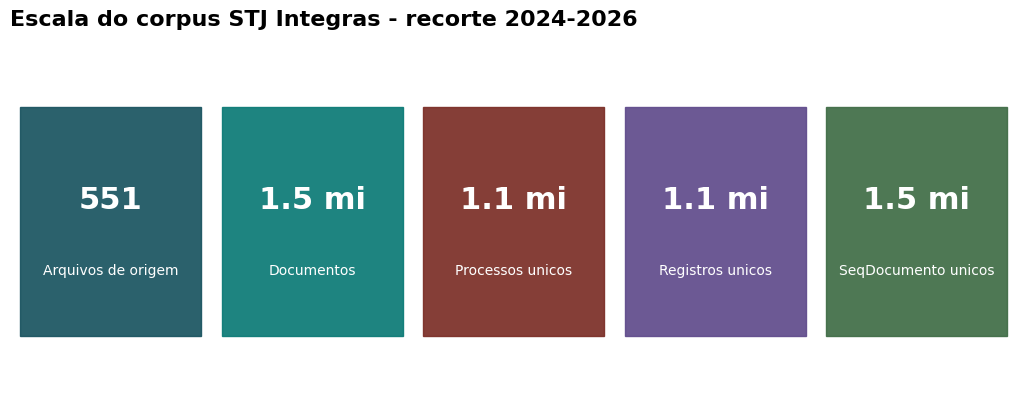

{'Arquivos de origem': 551,
 'Documentos': 1540204,
 'Processos unicos': 1108814,
 'Registros unicos': 1103696,
 'SeqDocumento unicos': 1531033}

In [6]:
kpis = {
    'Arquivos de origem': parse_summary_number(summary_text, 'Arquivos de origem'),
    'Documentos': parse_summary_number(summary_text, 'Documentos'),
    'Processos unicos': parse_summary_number(summary_text, 'Processos unicos'),
    'Registros unicos': parse_summary_number(summary_text, 'Registros unicos'),
    'SeqDocumento unicos': parse_summary_number(summary_text, 'SeqDocumento unicos'),
}

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.axis('off')
colors = ['#19535f', '#0b7a75', '#7b2d26', '#5f4b8b', '#3f6c45']
for i, (label, value) in enumerate(kpis.items()):
    x = i / len(kpis)
    width = 0.18
    ax.add_patch(plt.Rectangle((x + 0.01, 0.18), width, 0.62, color=colors[i], alpha=0.92, transform=ax.transAxes))
    ax.text(x + 0.01 + width / 2, 0.55, compact_number(value), ha='center', va='center', color='white', fontsize=22, fontweight='bold', transform=ax.transAxes)
    ax.text(x + 0.01 + width / 2, 0.36, label, ha='center', va='center', color='white', fontsize=10, transform=ax.transAxes)
ax.set_title('Escala do corpus STJ Integras - recorte 2024-2026', loc='left', fontsize=16)
fig.savefig(FIGURES_DATA / '01_kpis_corpus.png', dpi=160, bbox_inches='tight')
plt.show()

kpis

## 4. Evolucao temporal

**Mensagem oral:** 2025 e o ano mais volumoso do recorte completo. 2026 ainda esta parcial, entao qualquer comparacao anual precisa ser feita com cuidado.

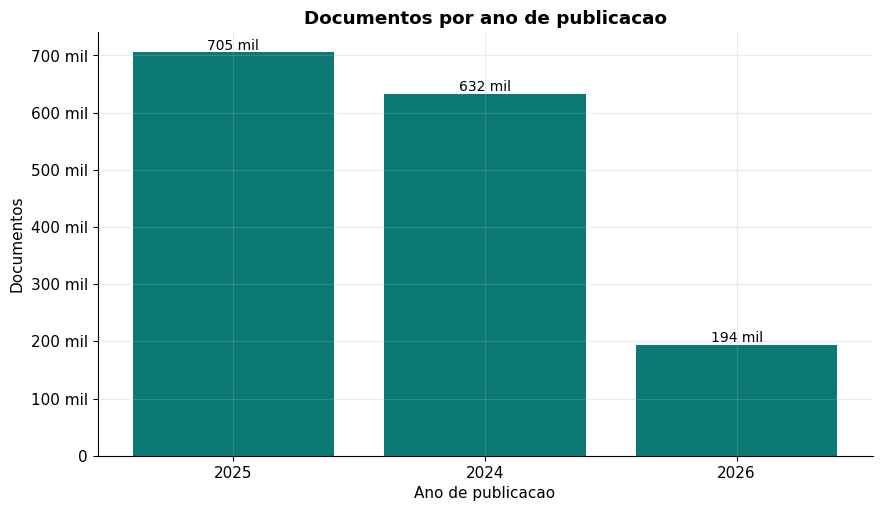

,ano_dataPublicacao,documentos
0,2025,705287
1,2024,632083
2,2026,193979


In [7]:
plot_year = docs_year.copy()
plot_year = plot_year[~plot_year['ano_dataPublicacao'].astype(str).eq('(vazio)')].copy()
plot_year['ano_dataPublicacao'] = plot_year['ano_dataPublicacao'].astype(float).astype(int).astype(str)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(plot_year['ano_dataPublicacao'], plot_year['documentos'], color='#0b7a75')
ax.set_title('Documentos por ano de publicacao')
ax.set_xlabel('Ano de publicacao')
ax.set_ylabel('Documentos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), compact_number(bar.get_height()), ha='center', va='bottom', fontsize=10)
fig.savefig(FIGURES_DATA / '02_documentos_por_ano.png', dpi=160, bbox_inches='tight')
plt.show()

plot_year

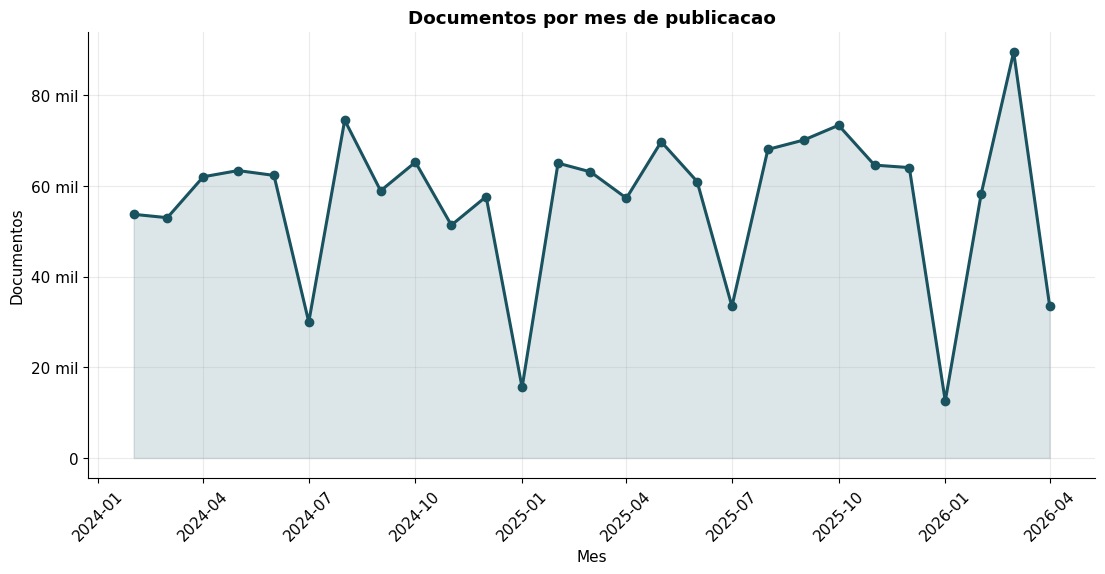

,mes_dataPublicacao,documentos
9,2025-12-01,64042
26,2026-01-01,12580
16,2026-02-01,58274
0,2026-03-01,89527
22,2026-04-01,33598


In [8]:
month = docs_month.copy()
month = month[~month['mes_dataPublicacao'].astype(str).isin(['NaT', '(vazio)'])].copy()
month['mes_dataPublicacao'] = pd.PeriodIndex(month['mes_dataPublicacao'], freq='M').to_timestamp()
month = month.sort_values('mes_dataPublicacao')

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.plot(month['mes_dataPublicacao'], month['documentos'], marker='o', linewidth=2.2, color='#19535f')
ax.fill_between(month['mes_dataPublicacao'], month['documentos'], alpha=0.15, color='#19535f')
ax.set_title('Documentos por mes de publicacao')
ax.set_xlabel('Mes')
ax.set_ylabel('Documentos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))
ax.tick_params(axis='x', rotation=45)
fig.savefig(FIGURES_DATA / '03_documentos_por_mes.png', dpi=160, bbox_inches='tight')
plt.show()

month.tail()

## 5. Documentos e resultados decisorios

**Mensagem oral:** a base mistura decisoes monocraticas e acordaos. Em termos de teor, predominam documentos que negam ou nao conhecem recursos/pedidos, o que e crucial para pensar a funcao institucional do STJ como tribunal de precedentes e filtro recursal.

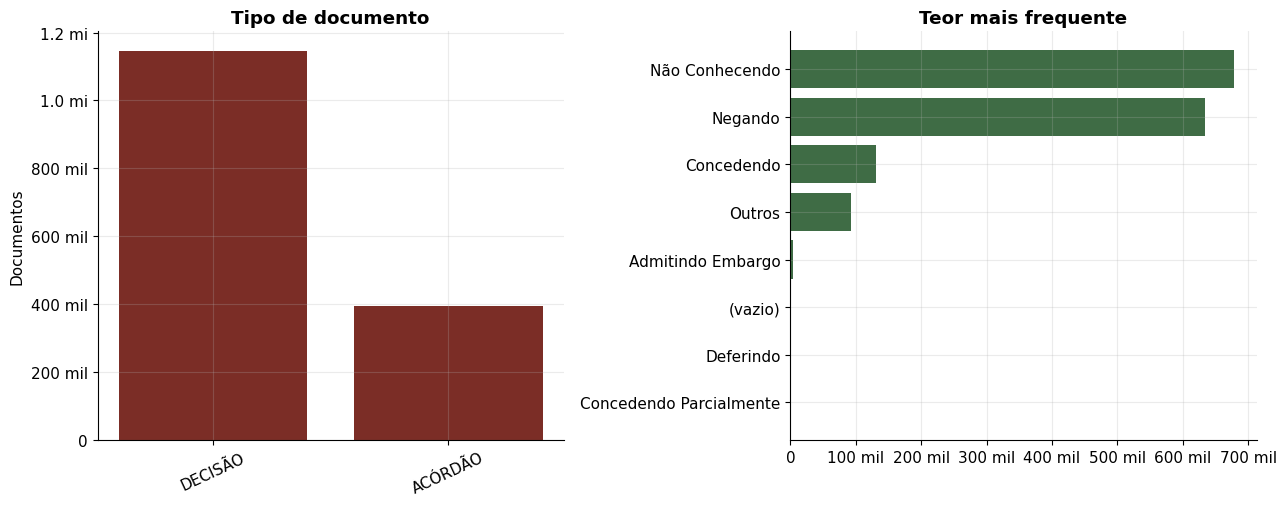

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

type_plot = docs_type.head(10).copy()
axes[0].bar(type_plot['tipoDocumento'], type_plot['documentos'], color='#7b2d26')
axes[0].set_title('Tipo de documento')
axes[0].set_ylabel('Documentos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))
axes[0].tick_params(axis='x', rotation=25)

teor_plot = docs_teor.head(8).iloc[::-1].copy()
axes[1].barh(teor_plot['teor'], teor_plot['documentos'], color='#3f6c45')
axes[1].set_title('Teor mais frequente')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))

fig.tight_layout()
fig.savefig(FIGURES_DATA / '04_tipo_e_teor.png', dpi=160, bbox_inches='tight')
plt.show()

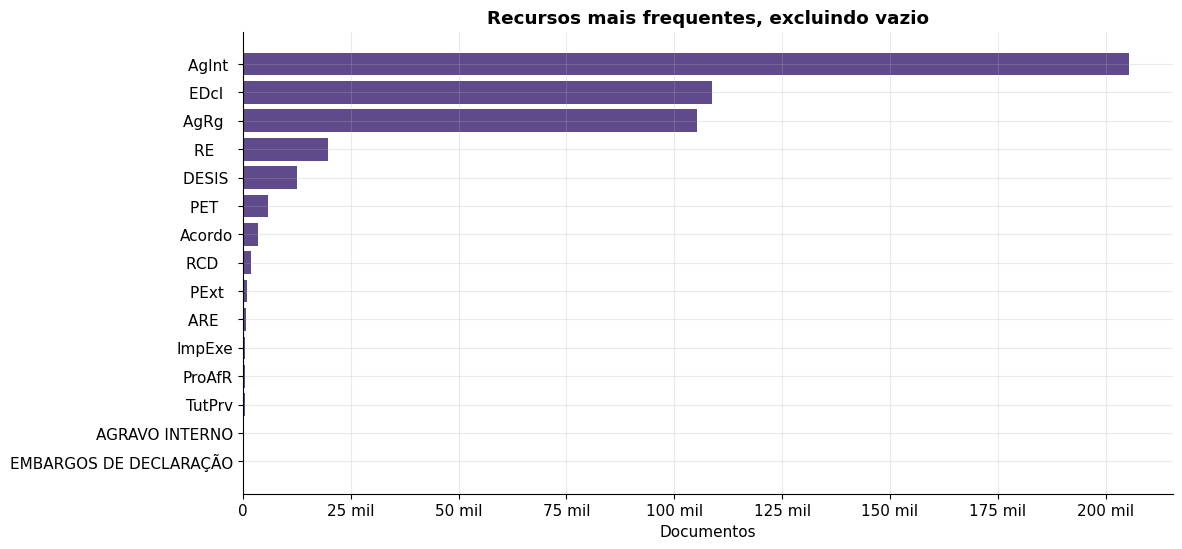

,recurso,documentos
5,DESIS,12640
4,RE,19807
3,AgRg,105215
2,EDcl,108797
1,AgInt,205340


In [10]:
recurso_plot = docs_recurso.copy()
recurso_plot = recurso_plot[~recurso_plot['recurso'].astype(str).eq('(vazio)')].head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(recurso_plot['recurso'], recurso_plot['documentos'], color='#5f4b8b')
ax.set_title('Recursos mais frequentes, excluindo vazio')
ax.set_xlabel('Documentos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))
fig.savefig(FIGURES_DATA / '05_recursos.png', dpi=160, bbox_inches='tight')
plt.show()

recurso_plot.tail()

## 6. Relatoria nos metadados

**Mensagem oral:** depois de combinar `ministro`, `NM_MINISTRO` e `relator`, o campo passa a ser informativo para concentração documental por relator no STJ. Ainda assim, ele descreve documentos do corpus STJ, não a vida completa do processo em todas as instâncias.

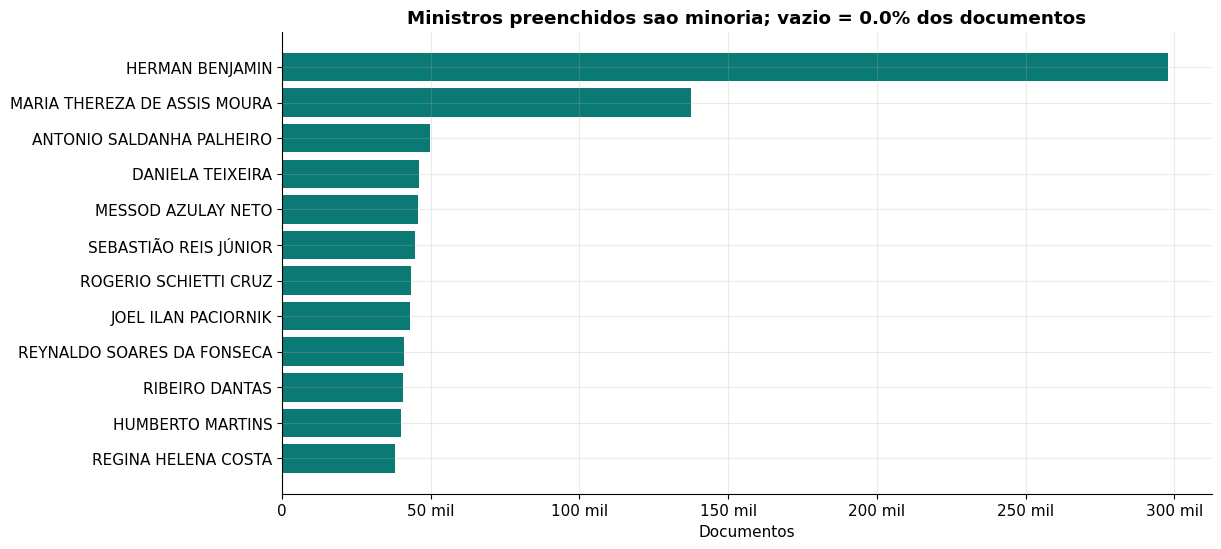

,ministro,documentos,is_vazio
0,HERMAN BENJAMIN,297777,False
1,MARIA THEREZA DE ASSIS MOURA,137641,False
2,ANTONIO SALDANHA PALHEIRO,49692,False
3,DANIELA TEIXEIRA,45953,False
4,MESSOD AZULAY NETO,45643,False
5,SEBASTIÃO REIS JÚNIOR,44857,False
6,ROGERIO SCHIETTI CRUZ,43398,False
7,JOEL ILAN PACIORNIK,43100,False
8,REYNALDO SOARES DA FONSECA,41068,False
9,RIBEIRO DANTAS,40823,False


In [11]:
minister = docs_minister.copy()
minister['is_vazio'] = minister['ministro'].astype(str).eq('(vazio)')
empty_minister = int(minister.loc[minister['is_vazio'], 'documentos'].sum()) if minister['is_vazio'].any() else 0
non_empty = minister.loc[~minister['is_vazio']].head(12).iloc[::-1]

total_docs = int(docs_year.loc[~docs_year['ano_dataPublicacao'].astype(str).eq('(vazio)'), 'documentos'].sum()) + int(docs_year.loc[docs_year['ano_dataPublicacao'].astype(str).eq('(vazio)'), 'documentos'].sum() if docs_year['ano_dataPublicacao'].astype(str).eq('(vazio)').any() else 0)
empty_pct = empty_minister / total_docs if total_docs else np.nan

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(non_empty['ministro'], non_empty['documentos'], color='#0b7a75')
ax.set_title(f'Ministros preenchidos sao minoria; vazio = {empty_pct:.1%} dos documentos')
ax.set_xlabel('Documentos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))
fig.savefig(FIGURES_DATA / '06_ministros_preenchidos.png', dpi=160, bbox_inches='tight')
plt.show()

minister.head(10)

## 7. Concentracao tematica

**Mensagem oral:** os assuntos mostram concentracao penal, mas os nomes estao sendo usados como rotulos auxiliares dos codigos. Neste momento, a fonte local do lookup e a tabela da Justica Federal de 1º Grau; portanto, nao devo apresentar a coluna `instancia` como cobertura real de todas as instancias. Para a apresentacao, o ponto forte e a concentracao dos **codigos de assunto**; o enriquecimento textual e provisório e precisa ser ampliado com tabelas de outras instancias/CNJ.

In [ ]:
assuntos_plot = assuntos_final.copy()
label_col = 'assunto' if 'assunto' in assuntos_plot.columns else 'assunto_final'
assuntos_plot[label_col] = assuntos_plot[label_col].fillna('(sem rotulo)')
assuntos_plot['rotulo'] = assuntos_plot['assunto_final'].astype(str).str.zfill(5) + ' - ' + assuntos_plot[label_col].astype(str)
assuntos_plot = assuntos_plot.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(13, 7.5))
ax.barh(assuntos_plot['rotulo'], assuntos_plot['ocorrencias'], color='#7b2d26')
ax.set_title('Codigos finais de assunto mais frequentes')
ax.set_xlabel('Ocorrencias')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))
fig.savefig(FIGURES_DATA / '07_top_assuntos.png', dpi=160, bbox_inches='tight')
plt.show()

assuntos_plot[['assunto_final', 'assunto', 'ocorrencias', 'caminho_assuntos', 'rotulo']].tail()

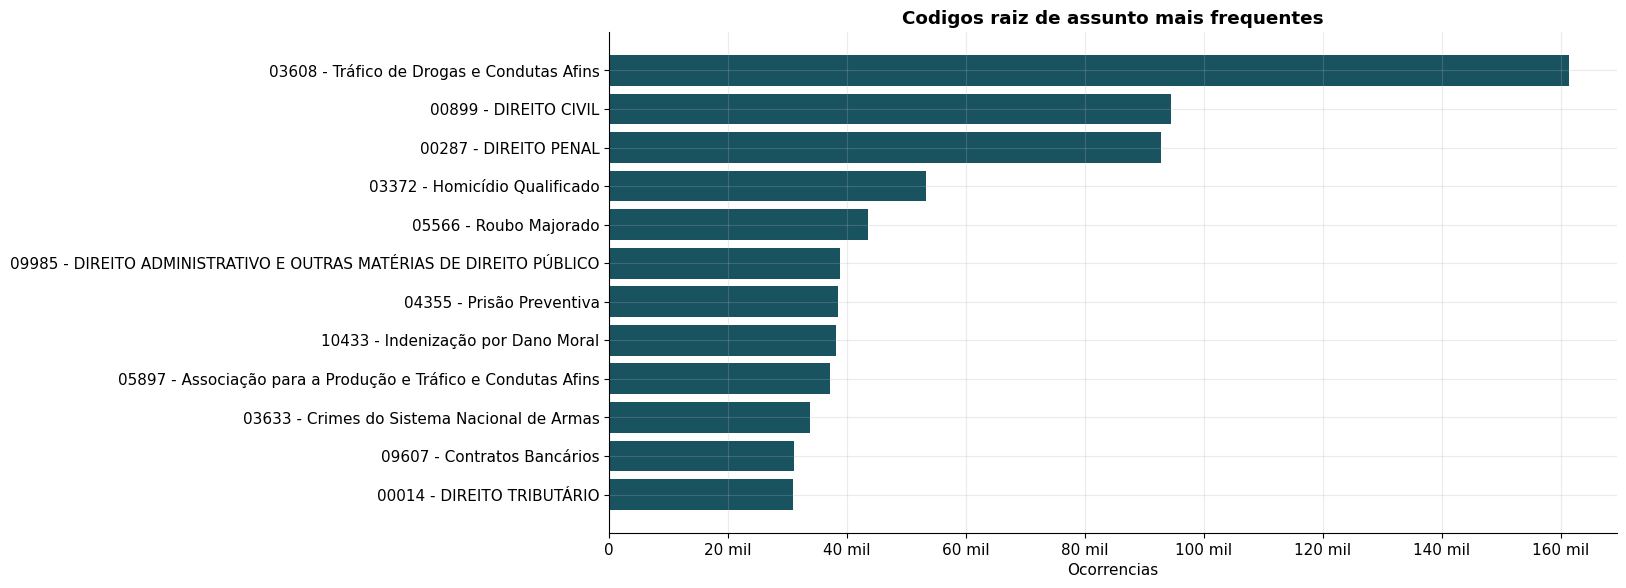

In [13]:
if not assuntos_root.empty and {'assunto_raiz', 'ocorrencias'}.issubset(assuntos_root.columns):
    root_plot = assuntos_root.copy()
    label_col = 'assunto' if 'assunto' in root_plot.columns else 'assunto_raiz'
    root_plot[label_col] = root_plot[label_col].fillna('(sem rotulo)')
    root_plot['rotulo'] = root_plot['assunto_raiz'].astype(str).str.zfill(5) + ' - ' + root_plot[label_col].astype(str)
    root_plot = root_plot.head(12).iloc[::-1]

    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.barh(root_plot['rotulo'], root_plot['ocorrencias'], color='#19535f')
    ax.set_title('Codigos raiz de assunto mais frequentes')
    ax.set_xlabel('Ocorrencias')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: compact_number(x)))
    fig.savefig(FIGURES_DATA / '08_assuntos_raiz.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('Tabela de assuntos raiz nao disponivel.')

## 8. Limite atual: vida processual completa

**Mensagem oral:** esta parte nao deve ser vendida como resultado final. Ela mostra que a camada documental esta forte, mas a espinha dorsal processo-CNJ ainda precisa ser consolidada. A vida processual completa exigira juntar `numeroRegistro`, CNJ, Atas de Distribuicao, Movimentacao Processual, DataJud e possivelmente dados de outras instancias.

In [ ]:
def parse_ciclo_metric(label: str) -> int | None:
    return parse_summary_number(ciclo_text, label)

ciclo_metrics = {
    'Processos na espinha dorsal': parse_ciclo_metric('Processos na espinha dorsal'),
    'Eventos de distribuicao/registro na ata': parse_ciclo_metric('Eventos de distribuicao/registro na ata'),
    'Movimentos DataJud': parse_ciclo_metric('Movimentos DataJud'),
    'Documentos no manifesto': parse_ciclo_metric('Documentos de integras no manifesto'),
    'Chaves auxiliares no corpus': parse_ciclo_metric('Chaves auxiliares no corpus textual'),
}

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis('off')
text = '\n'.join(f'{k}: {compact_number(v)}' for k, v in ciclo_metrics.items())
ax.text(0.02, 0.78, 'Limite metodologico: ligacao processual ainda incompleta', fontsize=17, fontweight='bold', transform=ax.transAxes)
ax.text(0.02, 0.58, text, fontsize=14, va='top', transform=ax.transAxes)
ax.text(
    0.55,
    0.58,
    'Leitura: ja ha um corpus documental amplo, mas a chave processo-CNJ ainda nao esta resolvida para a espinha dorsal.\n\nIsso nao invalida a EDA; delimita o proximo problema de engenharia de dados.',
    fontsize=12,
    va='top',
    transform=ax.transAxes,
)
fig.savefig(FIGURES_DATA / '09_limite_ciclo_vida.png', dpi=160, bbox_inches='tight')
plt.show()

ciclo_metrics

## 9. Fechamento para a apresentacao

**Tres conclusoes defensaveis agora:**

1. O corpus 2024-2026 e grande e operacionalizavel: mais de um milhao de documentos e processos unicos nos metadados.
2. A base tem concentracoes claras: decisoes predominam, o teor e fortemente concentrado em `Nao Conhecendo` e `Negando`, e assuntos penais aparecem no topo.
3. A pesquisa agora tem dois caminhos tecnicos bem definidos: baixar/processar os ZIPs de texto em lote e resolver a ligacao longitudinal processo-CNJ-registro STJ, eventualmente incorporando dados de outras instancias.

**Frase de transicao para o professor:**

> A EDA sugere que a base STJ e viavel para pesquisa empirica com LLMs, mas a etapa critica nao e apenas textual: e construir uma unidade processual confiavel, capaz de conectar documento, registro STJ, CNJ e, quando possivel, dados de outras instancias.

## 10. Figuras exportadas

In [15]:
exported = sorted(FIGURES_DATA.glob('*.png'))
print('Figuras exportadas:', len(exported))
for path in exported:
    print('-', path)

Figuras exportadas: 9
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/01_kpis_corpus.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/02_documentos_por_ano.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/03_documentos_por_mes.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/04_tipo_e_teor.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/05_recursos.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/06_ministros_preenchidos.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/07_top_assuntos.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/08_assuntos_raiz.png
- /content/drive/MyDrive/Mestrado/2026/llms/data/reports/figures/apresentacao_eda/09_limite_ciclo_vida.png
